Does the stddev increase as k=n_folds approaches N=npoints?
n_folds 2
order 20 mean 1.0351924130982098 stddev 0.020565748238607573
order 21 mean 1.0340855788056103 stddev 0.0180939981741417
order 22 mean 1.0342338773860384 stddev 0.017554210098886136
order 23 mean 1.0345478428283368 stddev 0.01567123192840103
order 24 mean 1.043173366002042 stddev 0.009839247171680165
order 25 mean 1.0443200358064821 stddev 0.009052175066408541
order 26 mean 1.0522695154986645 stddev 0.014260528011434626
order 27 mean 1.0551871033732416 stddev 0.014075062929716609
order 28 mean 1.0524553307670588 stddev 0.012644844229524721
order 29 mean 1.0517343497920244 stddev 0.012761939181507254
n_folds 4
order 20 mean 1.0309415753767328 stddev 0.024407314171482623
order 21 mean 1.0287694875671927 stddev 0.023124922764849797
order 22 mean 1.0290843547784938 stddev 0.022536354384936667
order 23 mean 1.030708395225421 stddev 0.025029358770126017
order 24 mean 1.0328322704076052 stddev 0.01915040223480617
order 25 me

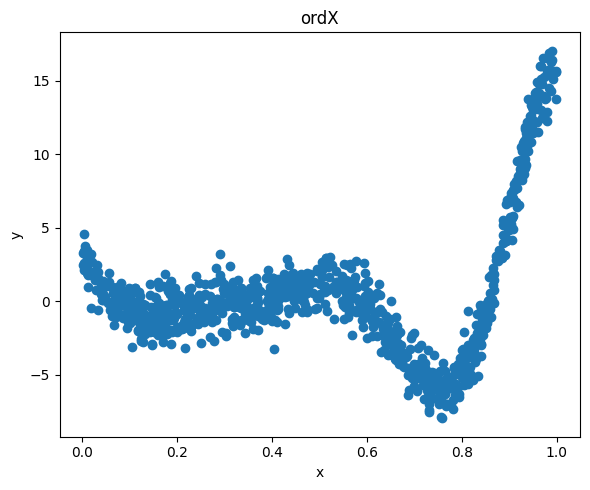

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

In [1]:
import sys
# todo Windows
sys.path.append("../cpcrr")


import cpcrr as cp


if __name__ == '__main__':

    f = cp.functions.onevar

    xmin = 0
    xmax = 1

    x, y = cp.functions.function_noise_1d(f, xmin = xmin, xmax = xmax, npoints=2**10, stddev = 1.0)
    cp.functions.quickplot_scatter(x, y, f"Data set")

    PF = cp.methods.Polynomial1DFitter(xmin, xmax, x, y)

    print("Does the stddev increase as k=n_folds approaches N=npoints?")
    n_folds = 2
    for n_folds_pow in range(1,11):
        min_order = 20
        max_order = 30
        print(f"n_folds {n_folds}")
        for order in range(min_order, max_order):
            loss, mean, stddev = PF.fit_and_cross_validate(order=order, n_folds=n_folds, plot = False, seed = 140)
            print(f"order {order} mean {mean} stddev {stddev}")
        n_folds *= 2


